## Problem Statement
You have a robot that crawls on the ocean floor. Its only sensors are a compass and a depth sensor. It also has access to an accurate bathymetric map of its surrounding area. How would your robot find its location on the ocean floor without GPS? Assume constant velocity. 

## Setup
observations:
- depth sensor
- compass heading
- velocity

state: 
$$
x = 
\begin{bmatrix}
p_1 \\ p_2 \\ v_1 \\ v_2
\end{bmatrix}
$$

dynamics:

$$
F = 
\begin{bmatrix}
1 & 0 & \Delta t  & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$


Observation function
$$
h(x) = 
\begin{bmatrix}
bath(p_1, p_2) \\ tan(\frac{p_2}{p_1}) \\ v_1 \\ v_2
\end{bmatrix}
$$

## Create Generate Simulated Bathymetric Map
The below code uses the sum of multiple **[Gaussian functions](https://en.wikipedia.org/wiki/Gaussian_function)** to create peaks and valleys for our simulated ocean floor:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import ipywidgets as widgets
import seaborn as sns

sns.set_theme(context='notebook', style='darkgrid')

In [2]:
# multi-gaussian surface
def gaussian_surface(x_in, centers, A, covs):
    """
    x_in:    (N, 1, 2, 1)
    centers: (1, M, 2, 1)
    A:       (1, M)
    covs:    (1, M, 2, 2)
    """
    d = x_in - centers
    cov_inv = np.linalg.inv(covs)

    q = d.transpose(0, 1, 3, 2) @ cov_inv @ d
    q = q.squeeze((-1, -2))

    heights = A * np.exp(-0.5 * q)

    return heights.sum(axis=1)

W, H = (75, 75)

x = np.linspace(-1, 1, W)
y = np.linspace(-1, 1, H)

mesh = np.meshgrid(x, y)
xv, yv = mesh

# (N, 1, 2, 1)
coords = np.stack([xv.ravel(), yv.ravel()], axis=1)
coords = coords[:, None, :, None]

# Centers: (1, M, 2, 1)
centers = np.array([
    [[-0.3], [ 0.0]],
    [[ 0.5], [ 0.3]],
    [[ 0.0], [-0.6]],
])[None]

# Heights: (1, M)
# Positive = peak, negative = valley
A = np.array([[10.0, 7.0, -4.0]])

# One covariance matrix per peak/valley: (1, M, 2, 2)
covs = np.array([
    [[0.08, 0.00],
     [0.00, 0.04]],

    [[0.2, 0.00],
     [0.00, 0.1]],

    [[0.15, 0.00],
     [0.00, 0.05]],
])[None]

z = gaussian_surface(coords, centers, A, covs).reshape(H, W)

## Visualize Bathymetry
We'll just plot our simulated ocean floor map

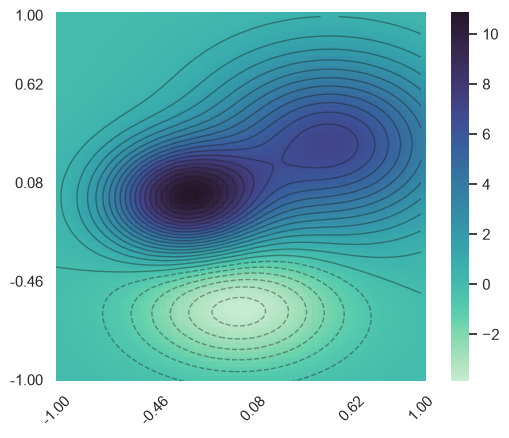

In [3]:
# Define a truncated color palette (10% less blacks)
base = plt.get_cmap("mako_r")
p = colors.LinearSegmentedColormap.from_list(
    "mako_truncated",
    base(np.linspace(0.05, 0.9, 256))  # truncate lower and upper color bounds
)


# Set heatmap axis labels
xtick_ixs = np.concat([np.arange(0, W, 20), [W - 1]])
xtick_labels = [f"{v:.2f}" for v in x[xtick_ixs]]

ytick_ixs = np.concat([np.arange(0, H, 20), [H - 1]])
ytick_labels = [f"{v:.2f}" for v in y[ytick_ixs]]

ax = sns.heatmap(z, cmap=p, square=True)
ax.invert_yaxis()

ax.set_xticks(xtick_ixs, labels=xtick_labels, rotation=45)
ax.set_yticks(ytick_ixs, labels=ytick_labels, rotation=0)

ax.contour(
    z,
    levels=25,
    colors='k',
    linewidths=1,
    alpha=0.4
)
plt.show()

## Likelihood
Recall that likelihood is defined as $p(z_k \mid x_k)$ for a fixed measurement $z_k$. It tells us the liklihood of that observation occuring over varying hypotheses $x_k$. To derive its form, we use the measurement model
<br>
$$
Z_t = h(X_t) + e, ~~~ e \sim \mathcal{N}(0, ~R) 
$$
<br>

$h(X_t)$ is the map from the state space (position) to the measurement space(depth). Assuming a fixed $X_t = x_t$, this gives us 

<br>
$$
p(Z_t \mid X_t = x_t) = \mathcal{N}(h(x_t), ~R)
$$
<br>

In the below code we will use the bathymetric map as our function $h$, which at each position gives us a depth:

## Visualizing Likelihood
The below code computes the likelihood as defined above, and visualizes it alongside the bathymetric map we created earlier. 

In [4]:
def normal_pdf(x, mean=0.0, std=1.0):
    variance = std ** 2
    denominator = np.sqrt(2 * np.pi * variance)
    numerator = np.exp(-((x - mean) ** 2) / (2 * variance))
    return numerator / denominator

likelihood = lambda obs: normal_pdf(obs, z)

In [5]:
min_depth = z.min()
max_depth = z.max()
@widgets.interact(
    observation=widgets.FloatSlider(value=0, min=min_depth, max=max_depth, description="Observation Depth", layout=widgets.Layout(width="60%"), style={"description_width": "15%"})
)
def likelihood_widget(observation):
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(z, cmap=p, ax=ax[0], square=True)
    sns.heatmap(likelihood(observation), ax=ax[1], xticklabels=False, yticklabels=False, square=True)

    ax[0].set_xticks(xtick_ixs, labels=xtick_labels, rotation=45)
    ax[0].set_yticks(ytick_ixs, labels=ytick_labels, rotation=0)
    ax[0].invert_yaxis()
    ax[1].invert_yaxis()

    ax[0].contour(
        z,
        levels=25,
        colors='k',
        linewidths=1,
        alpha=0.4
    )
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='Observation Depth', layout=Layout(width='60%'), max=…

# Update Step: $t=0$

## 1.1 Initial Prior probability
Because we are representing our distribution over a grid, the probability will be evenly distributed across all potentialstarting positions as $p(x_0) = \frac{1}{N}. 

## 1.2 Receive a Measurement
Let's just say it's depth = 0.

## 1.2 Apply Bayes Law
We will apply Bayes law. We have an initial prior and we defined the likelihood function in the previous section. Now we simply compute Bayes Law to get our first update, which will become the prior at the next time step. 

$$
p(x_0 \mid z_0) = \frac{p(x_0)p(z_0 \mid x_0)}{\int{p(x)p(z_0 \mid x)}dx}
$$

### 1.3 Update probability Code:

In [6]:
# Assume uniform distribution for positions on map
prior_x = np.ones(W) / W
prior_y = np.ones(H) / H

# belief distribution is the joint probability of each x with each y over the (H, W) grid. 
prior_distribution = np.prod(np.stack(np.meshgrid(prior_x, prior_y)), axis=0)

# First measurement
z0 = 0
like = likelihood(z0)
update = prior_distribution * like
update /= update.sum()

update.shape, update.sum()

((75, 75), np.float64(0.9999999999999999))

# Prediction Step

Recall that the prediction step is computing the law of total probability:

$$
p(x_k \mid z_{k - 1}) = \int p(x_k \mid x_{k - 1})p(x_{k - 1} \mid z_{k - 1}) dx_{k - 1}
$$

## 2. Transition Probability
The first term in the integrand is the transition distribution. 

$$
p(x_k \mid x_{k - 1})
$$


This distribution will be represented as an array with shape `(H, W, H, W)`. 

### 2.1 Array Shape Explanation
each possible prior location $x_{k - 1}^i$ for $i \in \{1, ... N\}$ is going to be associated with a distinct distribution, that gives the probability of moving from that prior position to any other position (or not moving at all). 

$$p_i(x_k \mid x_{k - 1}^i) ~~~ i \in \{1, \dots, N\}$$

Here, $N$ is the total size of the state space. In our case $N = rows \times cols$, or total number of (x, y) positions of our discrete state space grid.  Each one of these prior states will assign a probability to each new potential state $x_k^j$. So, there are $N = rows \times cols$ total starting positions, and $N = rows \times cols$ possible transitions for a total of $N^2$ discrete probabilities. We store eachprobability from each distribution in an `(rows, cols, rows, cols)` shaped array. 

### 2.2 Derive the Formula of Transition Probability

Our probabalistic model of motion, assuming constant velocity:

$$
X_k = X_{k - 1} + v\Delta t + W
$$

Assuming $W \sim \mathcal{N}(0, Q)$, we get:

$$
p(X_k | X_{k - 1} = x_{k - 1}) = \mathcal{N}(x_{k - 1} + v\Delta t, Q)
$$


### 2.3 Transition Probability Code

In [7]:
def multivariate_normal_pdf(x: np.ndarray, mu: np.ndarray, cov):
    """
    multivariate normal pdf.

    Computes the broadcasted multivariate probability density of all x with respect to all mu, therefore
    x and mu must have shapes compatable for broadcasting. 
    
    x: input with shape (ndim, ...)
    mu: mean with shape (ndim, ...)
    cov: Covariance with shape (ndim, ndim)
    """

    dim = x.shape[0]

    cov_inv = np.linalg.inv(cov)
    cov_det = np.linalg.det(cov)
    
    d = x - mu                 # (ndim, ...)
    d = np.moveaxis(d, 0, -1)  # (..., ndim)


    coefficient = (2 * np.pi)**(-dim / 2) * cov_det**(-1/2)
    
    quadratic = (
        d[..., None, :]   # (..., 1, ndim)
        @ cov_inv         # (ndim, ndim)    -- out -->  (..., 1, ndim)
        @ d[..., :, None] # (..., ndim, 1)  -- out -->  (..., 1, 1)
    ).squeeze((-1, -2))      

    return coefficient * np.exp(-0.5 * quadratic)
    

In [8]:
# fixed timestep and dynamics for constant velocity
dt = 0.1
v = np.asarray([0.1, 0.1])
Q = np.asarray([[1e-4, 0], [0, 1e-4]])

def F(x, v, dt):
    return x + dt * v

# Create a grid grid containing all possible permutations of state components... in this case positions (x_i, y_j)  
# For i in [0, ... W]) and j in [0 ... H]
x = np.linspace(-1, 1, W)
y = np.linspace(-1, 1, H)

# state[k, i, j] gives the value of state component k (k=0 for x, k=1 for y) for state permutation (x_i, y_j)
state_space = np.stack(np.meshgrid(x, y), axis=0)

# shape (2, H, W)
# transitions[k, i, j] is the result of applying dynamics component k of the state permutation (x_i, x_j)
transitions = F(state_space, v[:, None,None], dt)

state_space = state_space[:, None, None, ...] # (2, y_new, x_new) ---> (2, 1, 1, y_new, x_new)
transitions = transitions[..., None, None]    # (2, y_old, x_old) ---> (2, y_old, x_old, 1, 1)

# p(x_k | x_(k-1))
# transition_distribution[i, j, :, :] is the conditional density distribution given old position (x_j, y_i).
# transition_distribution[i, j, k, l] is the probability density of transitioning from original point (x_j, y_i) to new point (x_l, y_k).
transition_distribution = multivariate_normal_pdf(state_space, transitions, Q)

## 3. Performing Prediction

Now that we have the prior and all of the transition distributions, we multiply them together and sum over the dimension containing the prior probabilities. 

### 3.1 Prediction Code

In [9]:
# (old_y, old_x, new_y, new_x) * (old_y, old_x, 1, 1) 
prediction = transition_distribution * update[:, :, None, None]
prediction = prediction.sum((0, 1))
prediction /= prediction.sum()

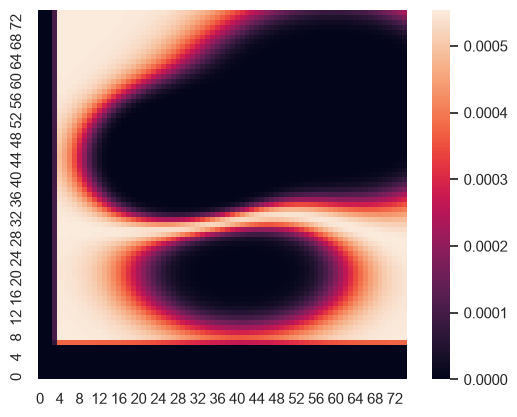

In [10]:
sns.heatmap(prediction, square=True).invert_yaxis()

## Algorithm In Loop
We'll put together the steps we just described and watch how the algorithm evolves our distributions over time. 